# Hockey Prediction

In [1]:
import data_service as dp
from team import Team
import ranking_regression as rr
import lin_regression as lr
import knn_regression as knn

In [2]:
X, y, df = dp.load()         # Lädt die Daten, bereitet sie vor und teilt sie in Features (X) und Zielvariable (y) auf   
print(f"Last 10 values of df: \n{df[['Home_Id', 'Away_Id', 'Home', 'Away', 'Resultat', 'OT/SO', 'Points']].head(10).to_string()}")
print(f"Features: {X.shape}")
#X.info()
print(X.head())
print(f"\nShape of target variable y: {y.shape}\n{y[:5]}")

Last 10 values of df: 
   Home_Id  Away_Id                       Home                Away Resultat OT/SO  Points
0        0       10            HC Ambri-Piotta          EHC Kloten      2:1   NaN       3
1        1       12                   HC Davos         Lausanne HC      4:1   NaN       3
2        2       11          Fribourg-Gottéron           HC Lugano      3:2    OT       2
3        3        8         Genève-Servette HC            HC Ajoie      5:3   NaN       3
4        4       13  SC Rapperswil-Jona Lakers          SCL Tigers      5:1   NaN       3
5        5        7                  ZSC Lions     EHC Biel-Bienne      4:3   NaN       3
6        6        9                     EV Zug             SC Bern      3:0   NaN       3
7        7        1            EHC Biel-Bienne            HC Davos      1:4   NaN       0
8        8        5                   HC Ajoie           ZSC Lions      0:4   NaN       0
9        9        3                    SC Bern  Genève-Servette HC      2:1  

## 1. Linear Regression

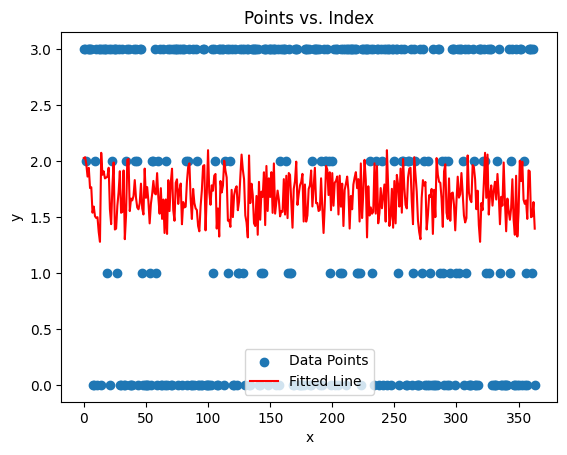

In [3]:
model=lr.fit(X, y) 
dp.plot_results(df, model)

Number of training items: 280, test items: 84
Training on rounds 0 to 39, testing on rounds 40 to 51


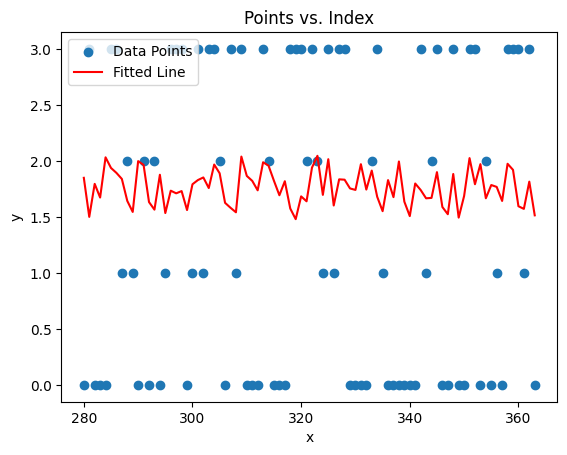

Predicted values y_hut) are rounded:
Model RMSE: 2.0557700445795186
Model R^2: -1.4581650317368715
Model Accuracy: 0.34523809523809523


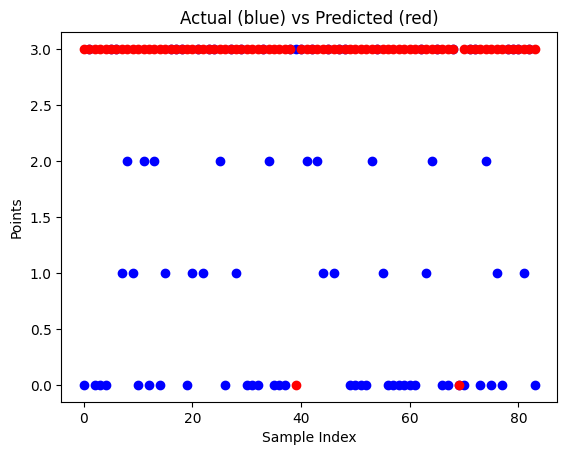

In [5]:
# train 40 Runden, test letzte 12 Runden
lr.analyze_model_performance(df=df, X=X, y=y, train_idx_start=0, train_idx_end=40, test_idx_start=40, test_idx_end=52)

Die vorausgesagten Punkte für sind letzten 12 Runden (84 Spiele) sind rot dargestellt und überschreiben die tatsächlichen Werte (blau). Je mehr man blaue Punkte sieht, desto schlechter ist das Modell. Die Accuracy von 0.35 ist entsprechend schlecht. Raten wäre vermutlich besser.

Aber: Die letzten Runden vor den Playoffs werden ganz anders gespielt wird und sind oft sehr unvorhersehbar sind, weil Teams, die schon qualifiziert sind, nicht mehr so motiviert sind, und Teams, die sich noch qualifizieren müssen, alles geben. Deshalb ist es vermutlich **falsch auf die ersten Runden zu trainieren und den letzten Runden zu testen.**

Number of training items: 70, test items: 70
Training on rounds 0 to 9, testing on rounds 10 to 19


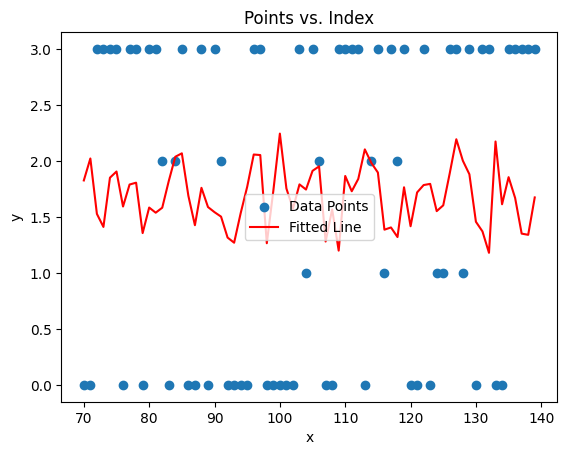

Predicted values y_hut) are rounded:
Model RMSE: 1.8935982376719422
Model R^2: -0.8763348996155484
Model Accuracy: 0.4857142857142857


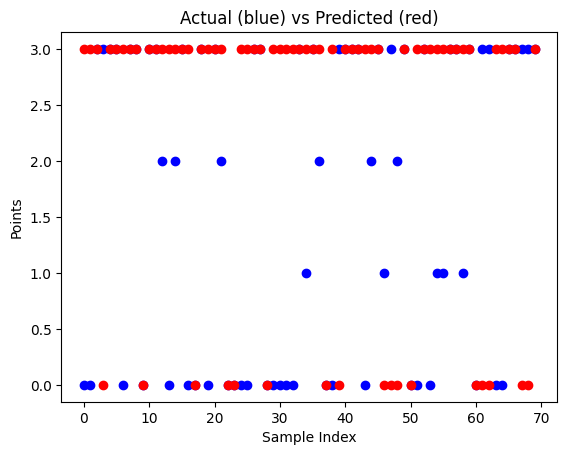

In [6]:
# train 10 Runden, test nächste 10 Runde
lr.analyze_model_performance(df=df, X=X, y=y, train_idx_start=0, train_idx_end=10, test_idx_start=10, test_idx_end=20) 

Was sich bestätigt, wenn auf die ersten 10 Runden trainiert und den nächsten 10 Runden testet, ist die Accuracy besser.

# 2. Vorausage nach Ranking

Vorhersage der Punkte basierend auf der Rangliste der Teams, die aus den vorherigen Spielen erstellt wird. Diese Taktik sollte man schlagen können.

In [ ]:
rr.analyze_model_performance(df,y, 40*7)

In [ ]:
Accuracy ist ca. 0.52, das ist %